In [3]:
def transform_continuous(continuous, raw, ycol, ymax=None, ymin=None, resample_rule=""):
    import numpy as np
    import pandas as pd

    # --- ensure ycol is list ---
    if isinstance(ycol, str):
        ycol = [ycol]

    # --- helper to normalize bounds ---
    def normalize_bounds(bound, ycol):
        if bound is None:
            return {col: None for col in ycol}
        if isinstance(bound, dict):
            return {col: bound.get(col, None) for col in ycol}
        if np.isscalar(bound):
            return {col: bound for col in ycol}
        if isinstance(bound, (list, tuple)):
            return dict(zip(ycol, bound))
        raise ValueError("ymax/ymin must be scalar, list, or dict")

    ymax_dict = normalize_bounds(ymax, ycol)
    ymin_dict = normalize_bounds(ymin, ycol)

    # --- RAW processing ---
    if "TimeStamp" in raw.columns.to_list():
        raw.set_index("TimeStamp", inplace=True)
    raw_ts = raw[["QO-REEL-ID-CUR-CALC", "QLS-PM1-BREAK-STATUS2", "2-008-P041_10-XI"]]

    reel_id_pb1 = [
        int(raw_ts.iloc[i]["QO-REEL-ID-CUR-CALC"])
        for i in np.where(
            (raw_ts["QLS-PM1-BREAK-STATUS2"] == 0)
            & (raw_ts["QLS-PM1-BREAK-STATUS2"].shift(1) != 0)
        )[0]
    ]

    reel_id_pb2 = [
        int(raw_ts.iloc[i]["QO-REEL-ID-CUR-CALC"])
        for i in np.where(
            (raw_ts["2-008-P041_10-XI"] > 50)
            & (raw_ts["2-008-P041_10-XI"].shift(-1) < 50)
        )[0]
    ]

    # --- FEATURE ENGINEERING ---
    continuous["grammage"] = continuous["AB_Grade_ID"].apply(lambda s: s - int(s / 1000) * 1000)
    continuous["paper_type"] = continuous["AB_Grade_ID"].apply(lambda s: int(s / 1000)).astype("string")

    continuous["Starch_uptake__g/m2_"] = (
        continuous["Starch_uptake_by_paper_Bottom_Roll__g/m2_"]
        + continuous["Starch_uptake_by_paper_Top_Roll__g/m2_"]
    )

    continuous["Fibre__g/m2_"] = (
        continuous["Current_basis_weight"]
        * (1 - continuous["Current_reel_moisture_average(reel)"] / 100)
        - continuous["Starch_uptake__g/m2_"]
    )

    # --- TIMESERIES ---
    continuous_ts = continuous.copy()
    continuous_ts.set_index("Wedge_Time", inplace=True)
    continuous_ts = continuous_ts[~continuous_ts.index.duplicated(keep="first")]
    continuous_ts = continuous_ts.sort_index()

    continuous_ts = continuous_ts[
        ~continuous_ts.MBS_Current_reel_ID.isin(reel_id_pb1 + reel_id_pb2)
    ]

    # --- OUTLIER FILTER per column ---
    for col in ycol:
        if ymax_dict[col] is not None:
            continuous_ts.loc[continuous_ts[col] > ymax_dict[col], col] = np.nan
        if ymin_dict[col] is not None:
            continuous_ts.loc[continuous_ts[col] < ymin_dict[col], col] = np.nan

    # --- TRANSITION LOGIC ---
    continuous_ts_ = continuous_ts.copy()

    transition_mask = (
        continuous_ts["MBS_Current_reel_ID"]
        != continuous_ts["MBS_Current_reel_ID"].shift(-1)
    )

    for col in ycol:
        temp = continuous_ts.loc[transition_mask, col]
        continuous_ts_[col] = np.nan
        continuous_ts_.loc[transition_mask, col] = temp

    # --- RESAMPLE ---
    if isinstance(continuous_ts_.index, pd.DatetimeIndex) and (resample_rule != ""):
        continuous_ts_ = continuous_ts_.resample(resample_rule).mean()

    return continuous_ts_

In [2]:
exog_vars = [
    "retention",
    #"grammage",
    'Current_basis_weight',
    "Speed",
    'Current_reel_moisture_average(SpeedSizer)',
    "Current_reel_moisture_average(reel)",
    'SpeedSizer_Linepressure_DS',
    'SpeedSizer_Linepressure_FS',
    "Starch_uptake__g/m2_",   
    'Consistency_starch_main_line',
    #'Draw_PD5-SS','Draw_AD7-PR','Draw_AD6-AD7','Draw_PD4-PD5','Draw_WS-PS','Draw_PD1-PD2','Draw_PD3-PD4','Draw_SS-AD6', 'Draw_PS-PD1','Draw_PD2-PD3',
    'Draw_PS-PD1',
    #"Linepressure_1st_press_FS__bar_", # Press Section
    #"Linepressure_2nd_press_FS__bar_", # Press Section
    #"Linepressure_1st_press_DS__bar_", # Press Section
    #"Linepressure_2nd_press_DS__bar_", # Press Section 
    "Linepressure_shoe_press__bar_", # Press Section 
    "pH_measurement_white_water_B41", # Forming Wire
    'Headbox_consistency',    
    "Lip_settings",
    "Jet/wire_ratio",
    #"Retention_Aid_mass_flow__g/T_", # Approach Flow
    #"Bentonite_1_mass_flow__g/T_", # Approach Flow
    #"Bentonite_2_mass_flow__g/T_", # Approach Flow   
    #"fibre_short/long"
]

In [20]:
import pandas as pd
import numpy as np

import seaborn as sns


sns.set(rc={"figure.figsize":(12, 4)})
sns.set_style('whitegrid')
sns.set_context('notebook')

In [5]:
continuous = pd.read_parquet(f"data/costimier_continuous.parquet", engine="pyarrow",)
raw = pd.read_parquet(f"phd/phd_all_casted.parquet", engine="pyarrow", columns=["TimeStamp","QO-REEL-ID-CUR-CALC", "QLS-PM1-BREAK-STATUS2", "2-008-P041_10-XI"])

In [71]:
[v for v in continuous.columns if "weight" in v.lower()]

['Current_reel_weight', 'Current_basis_weight']

# DynamicFactor

In [168]:
from utility import ewm_reset
from statsmodels.tsa.statespace.structural import UnobservedComponents
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

ewm_filtered = True
from_date = ""
grade = ""
ycol = ["MBS_SCT_CD", "MBS_SCT_MD", "MBS_Burst"] # can be str or list
ymax={"MBS_SCT_CD":2.5, "MBS_SCT_MD":3.8, "MBS_Burst":280}
ymin={"MBS_SCT_CD":1.0, "MBS_SCT_MD":2.2, "MBS_Burst":180}

# normalize ycol
if isinstance(ycol, str):
    ycol = [ycol]

continuous_ts = transform_continuous(continuous, raw, ycol, ymax, ymin)
continuous_ts["retention"] = 1 - continuous_ts["Consistency_white_water"] / (
    10 * continuous_ts["Headbox_consistency"]
)


continuous_ts = continuous_ts[continuous_ts.index<"2026-2-1"]

if ewm_filtered:
    grade_change = continuous_ts["AB_Grade_ID"].ne(continuous_ts["AB_Grade_ID"].shift())
    gap12 = continuous_ts.index.to_series().diff().gt(pd.Timedelta("12h")).fillna(True)
    continuous_ts["seg"] = (grade_change | gap12).cumsum()

    for c in exog_vars:
        continuous_ts[f"{c}_ewm"] = (
            continuous_ts.groupby("seg", group_keys=False)[c].transform(ewm_reset)
        )
    exog_vars_ = [f"{v}_ewm" for v in exog_vars]
else:
    exog_vars_ = exog_vars

if from_date:
    from_date = pd.to_datetime(from_date)
    continuous_ts = continuous_ts[continuous_ts.index > from_date]

hf = continuous_ts.copy()
if grade:
    hf = hf[hf.AB_Grade_ID == int(grade)]

test_frac = 0.20
split_loc = int(len(hf.index) * (1 - test_frac))

X_train_raw = hf.iloc[:split_loc][exog_vars_].astype(float)
X_test_raw = hf.iloc[split_loc:][exog_vars_].astype(float)

# y is now always a DataFrame
y_train = hf.iloc[:split_loc][ycol].astype(float)
y_test = hf.iloc[split_loc:][ycol].astype(float)

train_idx = X_train_raw.index
test_idx = X_test_raw.index

df_train_raw= pd.concat([X_train_raw, y_train], axis=1)
df_test_raw= pd.concat([X_test_raw, y_test], axis=1)

scaler = StandardScaler()
scaler.fit(X_train_raw)
X_train = pd.DataFrame(
    scaler.transform(X_train_raw),
    index=train_idx,
    columns=exog_vars_
)

X_test = pd.DataFrame(
    scaler.transform(X_test_raw),
    index=test_idx,
    columns=exog_vars_
)

# optional: if only one y column and you want Series instead of DataFrame
if len(ycol) == 1:
    y_train = y_train[ycol[0]]
    y_test = y_test[ycol[0]]



In [22]:
import seaborn as sns

sns.set(rc={"figure.figsize":(12, 4)})
sns.set_style('whitegrid')
sns.set_context('notebook')

In [183]:
import statsmodels.api as sm

mod = sm.tsa.DynamicFactor(
    endog=y_train,
    exog=X_train_raw,
    k_factors=1,
    factor_order=1,
    error_order=0,
    error_cov_type="diagonal"
)

c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [184]:
res = mod.fit(disp=False, maxiter=200)

c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [185]:
print(res.summary())

                                       Statespace Model Results                                      
Dep. Variable:     ['MBS_SCT_CD', 'MBS_SCT_MD', 'MBS_Burst']   No. Observations:               238064
Model:                     DynamicFactor(factors=1, order=1)   Log Likelihood              -32544.030
                                             + 15 regressors   AIC                          65192.060
Date:                                       Tue, 21 Apr 2026   BIC                          65731.835
Time:                                               16:34:25   HQIC                         65349.735
Sample:                                                    0                                         
                                                    - 238064                                         
Covariance Type:                                         opg                                         
Ljung-Box (L1) (Q):       0.01, 0.00, 0.00   Jarque-Bera (JB):   642821644.73, 651

In [143]:
sel_vars = exog_vars_

In [43]:
import numpy as np
import pandas as pd

def _align_and_mask(y_true, y_pred):
    """
    Align indices and keep only valid (non-NaN) pairs per column.
    """
    y_true, y_pred = y_true.align(y_pred, join="inner")
    return y_true, y_pred


def rmse_multi(y_true, y_pred):
    y_true, y_pred = _align_and_mask(y_true, y_pred)

    out = {}
    for col in y_true.columns:
        mask = y_true[col].notna() & y_pred[col].notna()
        if mask.sum() == 0:
            out[col] = np.nan
        else:
            err = y_true.loc[mask, col] - y_pred.loc[mask, col]
            out[col] = np.sqrt(np.mean(err**2))

    return pd.Series(out, name="rmse")


def mae_multi(y_true, y_pred): # your "mar" = MAE
    y_true, y_pred = _align_and_mask(y_true, y_pred)

    out = {}
    for col in y_true.columns:
        mask = y_true[col].notna() & y_pred[col].notna()
        if mask.sum() == 0:
            out[col] = np.nan
        else:
            err = np.abs(y_true.loc[mask, col] - y_pred.loc[mask, col])
            out[col] = np.mean(err)

    return pd.Series(out, name="mae")


def r2_multi(y_true, y_pred):
    y_true, y_pred = _align_and_mask(y_true, y_pred)

    out = {}
    for col in y_true.columns:
        mask = y_true[col].notna() & y_pred[col].notna()
        if mask.sum() < 2:
            out[col] = np.nan
        else:
            yt = y_true.loc[mask, col]
            yp = y_pred.loc[mask, col]
            ss_res = np.sum((yt - yp)**2)
            ss_tot = np.sum((yt - yt.mean())**2)
            out[col] = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return pd.Series(out, name="r2")

In [186]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

sel_vars = exog_vars_

fc = res.get_forecast(steps=len(test_idx), exog=X_test_raw[sel_vars])
y_pred_raw = fc.predicted_mean
y_pred_raw.index=index=y_test.index

y_test_obs = y_test.dropna()
y_pred_raw_obs = y_pred_raw.loc[y_test_obs.index]

rmse_test_raw = rmse_multi(y_test, y_pred_raw)
mae_test_raw = mae_multi(y_test, y_pred_raw)
r2_test_raw = r2_multi(y_test, y_pred_raw)


y_train_fit = res.get_prediction().predicted_mean
y_train_fit.index=y_train.index

rmse_train = rmse_multi(y_train, y_train_fit)
mae_train = mae_multi(y_train, y_train_fit)
r2_train = r2_multi(y_train, y_train_fit)

X_train_np = X_train_raw[sel_vars].to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = X_test_raw[sel_vars].to_numpy()
y_test_np = y_test.to_numpy()

endog_full = np.concatenate([y_train_np, y_test_np])
exog_full = np.vstack([X_train_np, X_test_np])

res_full = res.apply(endog=endog_full, exog=exog_full)
start = len(y_train_np)
end = len(endog_full) - 1
pred_full = res_full.get_prediction(start=start, end=end, information_set="predicted")

y_pred_filtered = pd.DataFrame(
    pred_full.predicted_mean.astype("float32"),
    index=y_test.index,
    columns=y_test.columns,
)


rmse_test_filtered = rmse_multi(y_test, y_pred_filtered)
mae_test_filtered = mae_multi(y_test, y_pred_filtered)
r2_test_filtered = r2_multi(y_test, y_pred_filtered)

c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [108]:
fitted_train = res.fittedvalues

# smoothed latent factor(s)
# shape usually (k_states, nobs), so transpose for convenience
smoothed_state = res.states.smoothed
smoothed_state.index = y_train.index

# first latent factor
latent_factor_train = smoothed_state.iloc[:, 0]

c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:2999: ValueWarning: No supported index is available. The `states` DataFrame uses a generated integer index
  warnings.warn('No supported index is available. The `states`'


In [189]:
r2_test_filtered

MBS_SCT_CD    0.916103
MBS_SCT_MD    0.848330
MBS_Burst     0.932908
Name: r2, dtype: float64

# Unobserved Components

In [22]:
from utility import ewm_reset
from statsmodels.tsa.statespace.structural import UnobservedComponents
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

ewm_filtered = False
from_date = ""
grade = ""
# ycol= "MBS_SCT_MD"
# ymax = 3.8
# ymin = 2.2
ycol= "MBS_SCT_CD"
ymax = 2.5
ymin = 1.0
continuous_ts = transform_continuous(continuous, raw, ycol=ycol, ymax=ymax, ymin=ymin)
continuous_ts["retention"] = 1 - continuous_ts["Consistency_white_water"] / (
    10 * continuous_ts["Headbox_consistency"]
)


if ewm_filtered:
    grade_change = continuous_ts["AB_Grade_ID"].ne(continuous_ts["AB_Grade_ID"].shift())
    gap12 = continuous_ts.index.to_series().diff().gt(pd.Timedelta("12h")).fillna(True)
    continuous_ts["seg"] = (grade_change | gap12).cumsum()
    for c in exog_vars:
        continuous_ts[f"{c}_ewm"] = continuous_ts.groupby("seg", group_keys=False)[c].transform(ewm_reset)
    exog_vars_ = [f"{v}_ewm" for v in exog_vars]
else:
    exog_vars_ = exog_vars


paper_type = pd.get_dummies(continuous_ts["paper_type"])
grammage_type = pd.get_dummies(continuous_ts["grammage"].astype(int).astype(str))
continuous_ts = pd.concat([continuous_ts, paper_type, grammage_type], axis=1)

#exog_vars_ += paper_type.columns.to_list()
#exog_vars_ += grammage_type.columns.to_list()


if from_date:
    from_date = pd.to_datetime(from_date)
    continuous_ts = continuous_ts[continuous_ts.index > from_date]

hf = continuous_ts.copy()
if grade:
    hf = hf[hf.AB_Grade_ID == int(grade)]

test_frac = 0.20
split_loc = int(len(hf.index) * (1 - test_frac))

X_train_raw = hf.iloc[:split_loc][exog_vars_].astype(float)
X_test_raw = hf.iloc[split_loc:][exog_vars_].astype(float)
y_train = hf.iloc[:split_loc][ycol].astype(float)
y_test = hf.iloc[split_loc:][ycol].astype(float)

train_idx = X_train_raw.index
test_idx = X_test_raw.index

scaler = StandardScaler()
scaler.fit(X_train_raw)

X_train = pd.DataFrame(scaler.transform(X_train_raw), index=train_idx, columns=exog_vars_)
X_test = pd.DataFrame(scaler.transform(X_test_raw), index=test_idx, columns=exog_vars_)



In [23]:
model = UnobservedComponents(
    endog=y_train.to_numpy(),    
    level='local level',
    autoregressive=None,
    exog=X_train_raw.to_numpy(),
    stochastic_level= True
)

c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\tsa\statespace\structural.py:426: SpecificationWarning: Value of `stochastic_level` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"


In [24]:
res = model.fit(method='lbfgs', maxiter=1500, disp=False)

c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\tsa\filters\hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


In [133]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

sel_vars=exog_vars_
 
fc = res.get_forecast(steps=len(test_idx), exog=X_test_raw[sel_vars])
y_pred_raw = pd.Series(fc.predicted_mean, index=y_test.index, name="y_pred_raw")

y_test_obs = y_test.dropna()
y_pred_raw_obs = y_pred_raw.loc[y_test_obs.index]

rmse_test_raw = root_mean_squared_error(y_test_obs, y_pred_raw_obs)
mae_test_raw = mean_absolute_error(y_test_obs, y_pred_raw_obs)
r2_test_raw = r2_score(y_test_obs, y_pred_raw_obs)

In [134]:
r2_test_raw

0.7856183475232966

In [ ]:
res.model.

In [101]:
res = model 

In [ ]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

X_train = pd.DataFrame(scaler.transform(X_train_raw), index=train_idx, columns=exog_vars_)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),  index=test_idx,  columns=exog_vars_)

y_train = hf.iloc[:split_loc][ycol].astype(float)
y_test  = hf.iloc[split_loc:][ycol].astype(float)

X_train_np = X_train_raw.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np  = X_test_raw.to_numpy()
y_test_np  = y_test.to_numpy()

# 1. Build full series (train + test)
endog_full = np.concatenate([y_train_np, y_test_np])
exog_full  = np.vstack([X_train_np, X_test_np])

# 2. Apply the *existing* parameters to the full dataset
#    (no refit, just re-run the filter)
res_full = res.apply(endog=endog_full, exog=exog_full)

# 3. Get 1-step-ahead predictions for the *test* region
start = len(y_train_np)      # first test index in full series
end   = len(endog_full) - 1  # last index

pred_full = res_full.get_prediction(
    start=start,
    end=end,
    information_set="predicted"  # one-step-ahead
)

y_pred = pred_full.predicted_mean.astype("float32")
y_pred = pd.Series(y_pred, index=y_test.index, name="y_pred")


y_test_obs = y_test.dropna()
y_pred_obs  = y_pred.loc[y_test_obs.index]


print(f"RMSE: {root_mean_squared_error(y_test_obs, y_pred):.3f}, MAE: {mean_absolute_error(y_test_obs, y_pred):.3f}, R2: {r2_score(y_test_obs, y_pred):.3f}")

In [26]:
from tqdm import tqdm
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
 
preds = []
lower = []
upper = []
indices = []
values = []

 
refit_every = 50
valid_count = 0
 
endog_refit = np.asarray(res.model.data.orig_endog).reshape(-1)
exog_refit = np.asarray(res.model.data.orig_exog) if res.model.data.orig_exog is not None else None
 
model_cls = res.model.__class__
init_kwargs = res.model._get_init_kwds().copy()
 
n = len(X_test_raw)

for i in tqdm(range(n), total=n, desc="Recursive prediction"):
 
    x_row = X_test_raw.iloc[[i]].to_numpy()
    y_true = y_test.iloc[i]
 
    fcst = res.get_forecast(steps=1, exog=x_row)
    y_hat = fcst.predicted_mean[0]
    ci = fcst.conf_int()
 
    preds.append(y_hat)
    lower.append(ci[0, 0])
    upper.append(ci[0, 1])
    indices.append(y_test.index[i])
    values.append(y_test.values[i])

 
    if pd.notna(y_true):
        y_row = np.array([y_true])
 
        res = res.append(endog=y_row, exog=x_row, refit=False)
 
        endog_refit = np.concatenate([endog_refit, y_row])
        if exog_refit is not None:
            exog_refit = np.vstack([exog_refit, x_row])
 
        valid_count += 1
 
        if valid_count % refit_every == 0:
            print(f"Full refit at index {i}, timestamp {y_test.index[i]}")
 
            refit_mod = model_cls(
                endog=endog_refit,
                exog=exog_refit,
                **init_kwargs
            )
            res = refit_mod.fit(start_params=res.params, disp=False)
 
pred_df = pd.DataFrame(
    {
        "y_true": values,
        "y_pred": preds,
        "lower": lower,
        "upper": upper,
    },
    index=indices,
)
 
df_eval = pred_df.dropna(subset=["y_true"])
df_eval.index.names = ['Wedge_Time']
 
rmse = np.sqrt(mean_squared_error(df_eval["y_true"], df_eval["y_pred"]))
mae = mean_absolute_error(df_eval["y_true"], df_eval["y_pred"])
r2 = r2_score(df_eval["y_true"], df_eval["y_pred"])
 
print("N:", len(df_eval))
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
 

Recursive prediction:   4%|▎         | 2404/65282 [03:44<56:15, 18.63it/s]  

Full refit at index 2411, timestamp 2025-12-23 02:57:00


Recursive prediction:   8%|▊         | 4984/65282 [08:01<51:51, 19.38it/s]   

Full refit at index 4994, timestamp 2026-01-04 00:43:00


Recursive prediction:  12%|█▏        | 7701/65282 [14:39<49:22, 19.44it/s]   

...

Full refit at index 62692, timestamp 2026-02-27 23:46:00


Recursive prediction: 100%|█████████▉| 65090/65282 [2:19:03<00:11, 17.24it/s]  

Full refit at index 65090, timestamp 2026-03-02 03:07:00


Recursive prediction: 100%|█████████▉| 65090/65282 [2:19:23<00:11, 17.24it/s]c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Recursive prediction: 100%|██████████| 65282/65282 [2:20:36<00:00,  7.74it/s]


N: 1254
RMSE: 0.05801621211153504
MAE: 0.04458149238661123
R2: 0.9173581655096285


In [20]:
import seaborn as sns


sns.set(rc={"figure.figsize":(12, 4)})
sns.set_style('whitegrid')
sns.set_context('notebook')

In [169]:
df_eval

,y_true,y_pred,lower,upper
Wedge_Time,,,,
2025-12-20 16:12:00,1.58,1.573375,1.478453,1.668297
2025-12-20 17:12:00,1.52,1.574693,1.480091,1.669296
2025-12-20 20:56:00,1.77,1.744638,1.650300,1.838976
2025-12-20 21:49:00,1.80,1.753887,1.659771,1.848003
2025-12-20 22:41:00,1.84,1.748824,1.654895,1.842752
...,...,...,...,...
2026-03-02 03:07:00,2.15,2.153023,2.058104,2.247941
2026-03-02 03:55:00,2.15,2.136953,2.042034,2.231871
2026-03-02 04:43:00,2.15,2.142322,2.047404,2.237241


<Axes: xlabel='Wedge_Time', ylabel='y_true'>

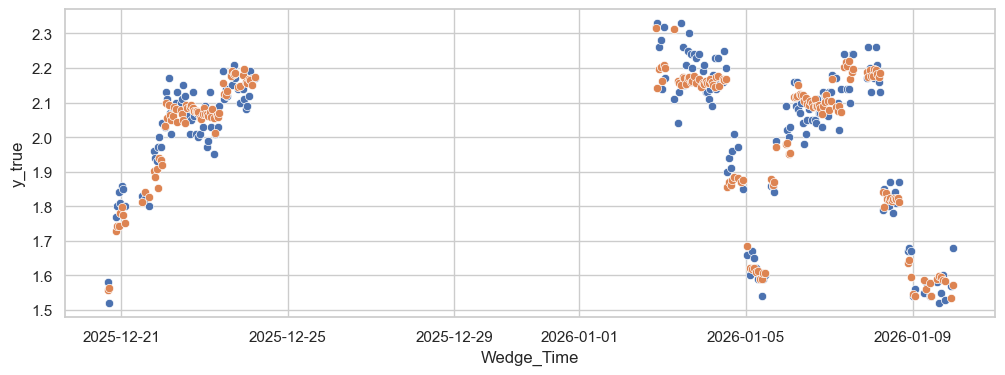

In [183]:
sns.scatterplot(df_eval[(df_eval.index>"2025-12-12") & (df_eval.index<"2026-1-10")].reset_index(), x="Wedge_Time", y="y_true")
sns.scatterplot(df_eval[(df_eval.index>"2025-12-12") & (df_eval.index<"2026-1-10")].reset_index(), x="Wedge_Time", y="y_pred")

# RidgePenalizedUC

In [185]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from statsmodels.tsa.statespace.structural import UnobservedComponents

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from statsmodels.tsa.statespace.structural import UnobservedComponents


class RidgePenalizedUC:
    def __init__(
        self,
        endog,
        exog=None,
        level="local level",
        ridge_alpha=1.0,
        standardize_exog=True,
        scaler=None,
        **uc_kwargs,
    ):
        self.level_ = level
        self.ridge_alpha = float(ridge_alpha)
        self.standardize_exog = standardize_exog
        self.uc_kwargs_ = dict(uc_kwargs)

        self.endog, self.endog_index_, _ = self._coerce_endog(endog)
        self.exog, self.exog_names_, _ = self._coerce_exog(exog)

        self._validate_alignment()

        # -------------------------
        # SCALING
        # -------------------------
        if self.exog is not None and self.standardize_exog:
            X = self._to_array(self.exog)

            if scaler is None:
                self.x_mean_ = X.mean(axis=0)
                self.x_std_ = X.std(axis=0)
                self.x_std_[self.x_std_ == 0] = 1.0
            else:
                self.x_mean_, self.x_std_ = scaler

            self.exog_scaled_ = (X - self.x_mean_) / self.x_std_
        else:
            self.x_mean_ = None
            self.x_std_ = None
            self.exog_scaled_ = self.exog

        self.model_ = UnobservedComponents(
            endog=self.endog,
            level=self.level_,
            exog=self.exog_scaled_,
            **self.uc_kwargs_,
        )

        self.param_names_ = list(self.model_.param_names)
        self.beta_idx_ = self._find_beta_indices()

        self.params_ = None
        self.result_ = None

    # -------------------------
    # Helpers
    # -------------------------
    def _to_array(self, X):
        return X.values if isinstance(X, pd.DataFrame) else np.asarray(X)

    def _coerce_endog(self, y):
        if isinstance(y, pd.Series):
            return y, y.index, y.name
        return np.asarray(y), None, None

    def _coerce_exog(self, X):
        if X is None:
            return None, None, None
        if isinstance(X, pd.DataFrame):
            return X.copy(), list(X.columns), X.index
        X = np.asarray(X)
        return X, [f"x{i}" for i in range(X.shape[1])], None

    def _validate_alignment(self):
        if self.exog is not None and len(self.endog) != len(self.exog):
            raise ValueError("endog and exog length mismatch")

    def _find_beta_indices(self):
        return np.array([
            i for i, n in enumerate(self.param_names_)
            if str(n).startswith("beta.")
        ])

    def _scale_new_exog(self, exog):
        if not self.standardize_exog or exog is None:
            return exog

        X = self._to_array(exog)
        return (X - self.x_mean_) / self.x_std_

    # -------------------------
    # Objective
    # -------------------------
    def _penalty(self, params):
        if len(self.beta_idx_) == 0:
            return 0.0
        beta = params[self.beta_idx_]
        return self.ridge_alpha * np.sum(beta**2)

    def _objective(self, unconstrained):
        params = self.model_.transform_params(unconstrained)
        ll = self.model_.loglike(params, transformed=True)
        return -ll + self._penalty(params)

    # -------------------------
    # Fit
    # -------------------------
    def fit(self, start_params=None, maxiter=500):
        if start_params is None:
            start_params = self.model_.fit(disp=False).params

        start_unconstrained = self.model_.untransform_params(start_params)

        res = minimize(
            self._objective,
            start_unconstrained,
            method="L-BFGS-B",
            options={"maxiter": maxiter}
        )

        params = self.model_.transform_params(res.x)

        self.params_ = params
        self.result_ = self.model_.smooth(params, transformed=True)
        return self

    # -------------------------
    # Coefficients
    # -------------------------
    @property
    def beta_series_(self):
        return pd.Series(
            self.params_[self.beta_idx_],
            index=self.exog_names_
        )

    @property
    def beta_original_scale_(self):
        if not self.standardize_exog:
            return self.beta_series_

        beta_std = self.params_[self.beta_idx_]
        beta_orig = beta_std / self.x_std_
        return pd.Series(beta_orig, index=self.exog_names_)

    # -------------------------
    # Forecast / Predict
    # -------------------------
    def forecast(self, steps, exog=None):
        exog = self._scale_new_exog(exog)
        return self.result_.forecast(steps=steps, exog=exog)

    def get_forecast(self, steps, exog=None):
        exog = self._scale_new_exog(exog)
        return self.result_.get_forecast(steps=steps, exog=exog)

    def predict(self, start=None, end=None):
        return self.result_.predict(start=start, end=end)

    # -------------------------
    # Append / Apply
    # -------------------------
    def append(self, endog, exog=None, refit=False):
        endog_all = np.concatenate([self._to_array(self.endog), self._to_array(endog)])

        if self.exog is not None:
            exog_all = np.vstack([
                self._to_array(self.exog),
                self._to_array(exog)
            ])
        else:
            exog_all = None

        new = RidgePenalizedUC(
            endog_all,
            exog_all,
            level=self.level_,
            ridge_alpha=self.ridge_alpha,
            standardize_exog=self.standardize_exog,
            scaler=(self.x_mean_, self.x_std_) if self.standardize_exog else None,
            **self.uc_kwargs_,
        )

        if refit:
            return new.fit(start_params=self.params_)
        else:
            new.params_ = self.params_
            new.result_ = new.model_.smooth(self.params_, transformed=True)
            return new

    def apply(self, endog, exog=None, refit=False):
        new = RidgePenalizedUC(
            endog,
            exog,
            level=self.level_,
            ridge_alpha=self.ridge_alpha,
            standardize_exog=self.standardize_exog,
            scaler=(self.x_mean_, self.x_std_) if self.standardize_exog else None,
            **self.uc_kwargs_,
        )

        if refit:
            return new.fit(start_params=self.params_)
        else:
            new.params_ = self.params_
            new.result_ = new.model_.smooth(self.params_, transformed=True)
            return new
        
    def get_prediction(self, start=None, end=None, dynamic=False, exog=None, **kwargs):
        if self.result_ is None:
            raise ValueError("Model is not fitted yet.")

        exog = self._scale_new_exog(exog)
        return self.result_.get_prediction(
            start=start,
            end=end,
            dynamic=dynamic,
            exog=exog,
            **kwargs
        )

In [191]:
from utility import ewm_reset
from statsmodels.tsa.statespace.structural import UnobservedComponents
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

ewm_filtered = False
from_date = ""
grade = ""
# ycol= "MBS_SCT_MD"
# ymax = 3.8
# ymin = 2.2
ycol= "MBS_SCT_CD"
ymax = 2.5
ymin = 1.0
continuous_ts = transform_continuous(continuous, raw, ycol=ycol, ymax=ymax, ymin=ymin)
continuous_ts["retention"] = 1 - continuous_ts["Consistency_white_water"] / (
    10 * continuous_ts["Headbox_consistency"]
)


if ewm_filtered:
    grade_change = continuous_ts["AB_Grade_ID"].ne(continuous_ts["AB_Grade_ID"].shift())
    gap12 = continuous_ts.index.to_series().diff().gt(pd.Timedelta("12h")).fillna(True)
    continuous_ts["seg"] = (grade_change | gap12).cumsum()
    for c in exog_vars:
        continuous_ts[f"{c}_ewm"] = continuous_ts.groupby("seg", group_keys=False)[c].transform(ewm_reset)
    exog_vars_ = [f"{v}_ewm" for v in exog_vars]
else:
    exog_vars_ = exog_vars

if from_date:
    from_date = pd.to_datetime(from_date)
    continuous_ts = continuous_ts[continuous_ts.index > from_date]

hf = continuous_ts.copy()
if grade:
    hf = hf[hf.AB_Grade_ID == int(grade)]

test_frac = 0.20
split_loc = int(len(hf.index) * (1 - test_frac))

X_train_raw = hf.iloc[:split_loc][exog_vars_].astype(float)
X_test_raw = hf.iloc[split_loc:][exog_vars_].astype(float)
y_train = hf.iloc[:split_loc][ycol].astype(float)
y_test = hf.iloc[split_loc:][ycol].astype(float)

train_idx = X_train_raw.index
test_idx = X_test_raw.index

scaler = StandardScaler()
scaler.fit(X_train_raw)

X_train = pd.DataFrame(scaler.transform(X_train_raw), index=train_idx, columns=exog_vars_)
X_test = pd.DataFrame(scaler.transform(X_test_raw), index=test_idx, columns=exog_vars_)



In [193]:
model = RidgePenalizedUC(
    endog=y_train,
    exog=X_train_raw,
    level="local level",
    ridge_alpha=5.0,
    standardize_exog=True
)

model.fit()

c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\tsa\filters\hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
X_train = pd.DataFrame(scaler.transform(X_train_raw), index=train_idx, columns=exog_vars_)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),  index=test_idx,  columns=exog_vars_)

y_train = hf.iloc[:split_loc][ycol].astype(float)
y_test  = hf.iloc[split_loc:][ycol].astype(float)

X_train_np = X_train_raw.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np  = X_test_raw.to_numpy()
y_test_np  = y_test.to_numpy()

# 1. Build full series (train + test)
endog_full = np.concatenate([y_train_np, y_test_np])
exog_full  = np.vstack([X_train_np, X_test_np])

# 2. Apply the *existing* parameters to the full dataset
#    (no refit, just re-run the filter)
res_full = model.apply(endog=endog_full, exog=exog_full)

# 3. Get 1-step-ahead predictions for the *test* region
start = len(y_train_np)      # first test index in full series
end   = len(endog_full) - 1  # last index

pred_full = res_full.get_prediction(
    start=start,
    end=end,
    information_set="predicted"  # one-step-ahead
)

y_pred = pred_full.predicted_mean.astype("float32")
y_pred = pd.Series(y_pred, index=y_test.index, name="y_pred")


y_test_obs = y_test.dropna()
y_pred_obs  = y_pred.loc[y_test_obs.index]

print(f"RMSE: {root_mean_squared_error(y_test_obs, y_pred):.3f}, MAE: {mean_absolute_error(y_test_obs, y_pred):.3f}, R2: {r2_score(y_test_obs, y_pred):.3f}")

RMSE: 0.056, MAE: 0.043, R2: 0.924


In [194]:
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

preds = []
lower = []
upper = []
indices = []
values = []

refit_every = 50
valid_count = 0

endog_refit = np.asarray(model.endog, dtype=float).reshape(-1)
exog_refit = np.asarray(model.exog, dtype=float) if model.exog is not None else None

n = len(X_test_raw)

for i in tqdm(range(n), total=n, desc="Recursive prediction"):

    x_row = X_test_raw.iloc[[i]].to_numpy(dtype=float)
    y_true = y_test.iloc[i]

    fcst = model.get_forecast(steps=1, exog=x_row)
    y_hat = float(np.asarray(fcst.predicted_mean).reshape(-1)[0])

    ci = np.asarray(fcst.conf_int(), dtype=float)
    preds.append(y_hat)
    lower.append(ci[0, 0])
    upper.append(ci[0, 1])
    indices.append(y_test.index[i])
    values.append(y_test.values[i])

    if pd.notna(y_true):
        y_row = np.array([float(y_true)], dtype=float)

        # fast update: same regularized params, just update state
        model = model.append(endog=y_row, exog=x_row, refit=False)

        endog_refit = np.concatenate([endog_refit, y_row])
        if exog_refit is not None:
            exog_refit = np.vstack([exog_refit, x_row])

        valid_count += 1

        if valid_count % refit_every == 0:
            print(f"Full regularized refit at index {i}, timestamp {y_test.index[i]}")

            model = RidgePenalizedUC(
                endog=endog_refit,
                exog=exog_refit,
                level=model.level_,
                ridge_alpha=model.ridge_alpha,
                standardize_exog=model.standardize_exog,
                scaler=(model.x_mean_, model.x_std_) if model.standardize_exog else None,
                **model.uc_kwargs_,
            ).fit(start_params=model.params_, maxiter=500)

pred_df = pd.DataFrame(
    {
        "y_true": values,
        "y_pred": preds,
        "lower": lower,
        "upper": upper,
    },
    index=indices,
)

df_eval = pred_df.dropna(subset=["y_true"])
df_eval.index.names = ['Wedge_Time']

rmse = np.sqrt(mean_squared_error(df_eval["y_true"], df_eval["y_pred"]))
mae = mean_absolute_error(df_eval["y_true"], df_eval["y_pred"])
r2 = r2_score(df_eval["y_true"], df_eval["y_pred"])

print("N:", len(df_eval))
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)



Recursive prediction:   0%|          | 0/65282 [00:00<?, ?it/s]c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integ

Full regularized refit at index 2411, timestamp 2025-12-23 02:57:00


Recursive prediction:   8%|▊         | 4986/65282 [18:17<1:33:57, 10.70it/s]  

Full regularized refit at index 4994, timestamp 2026-01-04 00:43:00


Recursive prediction:  12%|█▏        | 7702/65282 [31:34<1:41:34,  9.45it/s]  

...

Full regularized refit at index 62692, timestamp 2026-02-27 23:46:00


Recursive prediction: 100%|█████████▉| 65088/65282 [4:55:50<00:19, 10.17it/s]  

Full regularized refit at index 65090, timestamp 2026-03-02 03:07:00


Recursive prediction: 100%|██████████| 65282/65282 [4:59:37<00:00,  3.63it/s]


N: 1254
RMSE: 0.056992323780783095
MAE: 0.04391115020538029
R2: 0.920249403732732


<Axes: xlabel='Wedge_Time', ylabel='y_true'>

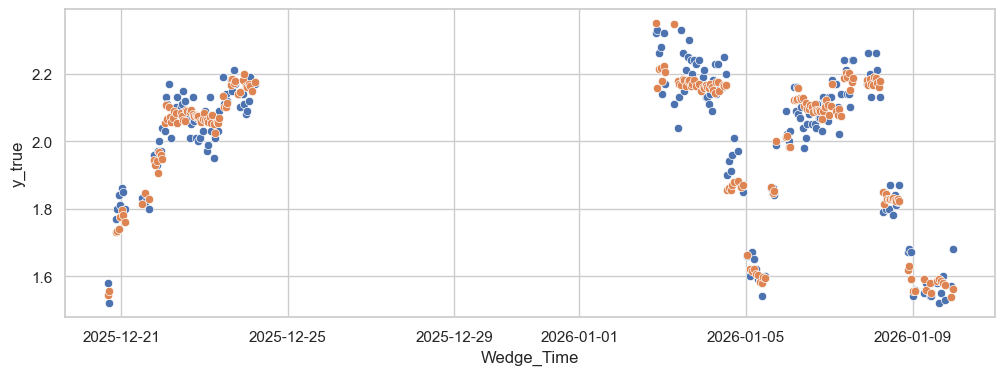

In [195]:
sns.scatterplot(df_eval[(df_eval.index>"2025-12-12") & (df_eval.index<"2026-1-10")].reset_index(), x="Wedge_Time", y="y_true")
sns.scatterplot(df_eval[(df_eval.index>"2025-12-12") & (df_eval.index<"2026-1-10")].reset_index(), x="Wedge_Time", y="y_pred")

# Ridge first, UOC on residuals

In [7]:
from utility import ewm_reset
from statsmodels.tsa.statespace.structural import UnobservedComponents
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

ewm_filtered = False
from_date = ""
grade = ""
# ycol= "MBS_SCT_MD"
# ymax = 3.8
# ymin = 2.2
ycol= "MBS_SCT_CD"
ymax = 2.5
ymin = 1.0
continuous_ts = transform_continuous(continuous, raw, ycol=ycol, ymax=ymax, ymin=ymin)
continuous_ts["retention"] = 1 - continuous_ts["Consistency_white_water"] / (
    10 * continuous_ts["Headbox_consistency"]
)


if ewm_filtered:
    grade_change = continuous_ts["AB_Grade_ID"].ne(continuous_ts["AB_Grade_ID"].shift())
    gap12 = continuous_ts.index.to_series().diff().gt(pd.Timedelta("12h")).fillna(True)
    continuous_ts["seg"] = (grade_change | gap12).cumsum()
    for c in exog_vars:
        continuous_ts[f"{c}_ewm"] = continuous_ts.groupby("seg", group_keys=False)[c].transform(ewm_reset)
    exog_vars_ = [f"{v}_ewm" for v in exog_vars]
else:
    exog_vars_ = exog_vars


paper_type = pd.get_dummies(continuous_ts["paper_type"])
grammage_type = pd.get_dummies(continuous_ts["grammage"].astype(int).astype(str))
continuous_ts = pd.concat([continuous_ts, paper_type, grammage_type], axis=1)

#exog_vars_ += paper_type.columns.to_list()
#exog_vars_ += grammage_type.columns.to_list()


if from_date:
    from_date = pd.to_datetime(from_date)
    continuous_ts = continuous_ts[continuous_ts.index > from_date]

hf = continuous_ts.copy()
if grade:
    hf = hf[hf.AB_Grade_ID == int(grade)]

test_frac = 0.20
split_loc = int(len(hf.index) * (1 - test_frac))

X_train_raw = hf.iloc[:split_loc][exog_vars_].astype(float)
X_test_raw = hf.iloc[split_loc:][exog_vars_].astype(float)
y_train = hf.iloc[:split_loc][ycol].astype(float)
y_test = hf.iloc[split_loc:][ycol].astype(float)

train_idx = X_train_raw.index
test_idx = X_test_raw.index

scaler = StandardScaler()
scaler.fit(X_train_raw)

X_train = pd.DataFrame(scaler.transform(X_train_raw), index=train_idx, columns=exog_vars_)
X_test = pd.DataFrame(scaler.transform(X_test_raw), index=test_idx, columns=exog_vars_)



In [13]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from statsmodels.tsa.statespace.structural import UnobservedComponents
import numpy as np
import pandas as pd

# X_train_raw: minute-level exog
# y_train: minute-level target with many NaNs

mask_obs = y_train.notna()

ridge = make_pipeline(
    StandardScaler(),
    Ridge(alpha=10.0)
)

ridge.fit(
    X_train_raw.loc[mask_obs],
    y_train.loc[mask_obs]
)

base_train = pd.Series(
    ridge.predict(X_train_raw),
    index=y_train.index,
    name="ridge_base"
)

resid_train = y_train - base_train
# resid_train has NaNs where y_train has NaNs

uc = UnobservedComponents(
    endog=resid_train.to_numpy(),
    level="local level"
)

res_uc = uc.fit(method="lbfgs", maxiter=1500, disp=False)

c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\tsa\filters\hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


In [15]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

base_test = pd.Series(
    ridge.predict(X_test_raw),
    index=y_test.index,
    name="ridge_base"
)

fc_resid = res_uc.get_forecast(
    steps=len(X_test_raw)
)

resid_pred = pd.Series(
    fc_resid.predicted_mean,
    index=y_test.index,
    name="resid_pred"
)

y_pred = base_test + resid_pred

mask_test_obs = y_test.notna()

rmse = root_mean_squared_error(y_test[mask_test_obs], y_pred[mask_test_obs])
mae = mean_absolute_error(y_test[mask_test_obs], y_pred[mask_test_obs])
r2 = r2_score(y_test[mask_test_obs], y_pred[mask_test_obs])

print(rmse, mae, r2)

0.08195772244209508 0.06574067690339705 0.8350770969432375


In [16]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from statsmodels.tsa.statespace.structural import UnobservedComponents
import numpy as np
import pandas as pd

# -----------------------------
# 1. Train/test data
# -----------------------------
y_train = hf.iloc[:split_loc][ycol].astype(float)
y_test = hf.iloc[split_loc:][ycol].astype(float)

X_train_raw = hf.iloc[:split_loc][exog_vars_].astype(float)
X_test_raw = hf.iloc[split_loc:][exog_vars_].astype(float)

# -----------------------------
# 2. Fit Ridge only where y is observed
# -----------------------------
mask_train_obs = y_train.notna()

ridge = make_pipeline(
    StandardScaler(),
    Ridge(alpha=10.0)
)

ridge.fit(
    X_train_raw.loc[mask_train_obs],
    y_train.loc[mask_train_obs]
)

# Static Ridge baseline
base_train = pd.Series(
    ridge.predict(X_train_raw),
    index=y_train.index,
    name="ridge_base"
)

base_test = pd.Series(
    ridge.predict(X_test_raw),
    index=y_test.index,
    name="ridge_base"
)

# -----------------------------
# 3. Build residual target
# -----------------------------
resid_train = y_train - base_train
resid_test = y_test - base_test

# Fit UOC on residuals.
# resid_train contains NaNs where y_train is missing.
uc = UnobservedComponents(
    endog=resid_train.to_numpy(),
    level="local level"
)

res = uc.fit(method="lbfgs", maxiter=1500, disp=False)

# -----------------------------
# 4. Apply residual UOC to full residual series
# -----------------------------
resid_full = pd.concat([resid_train, resid_test])

res_full = res.apply(
    endog=resid_full.to_numpy()
)

start = len(resid_train)
end = len(resid_full) - 1

pred_resid_full = res_full.get_prediction(
    start=start,
    end=end,
    information_set="predicted"
)

resid_pred = pd.Series(
    np.asarray(pred_resid_full.predicted_mean, dtype="float32"),
    index=y_test.index,
    name="resid_pred"
)

# -----------------------------
# 5. Final prediction = Ridge baseline + UOC residual
# -----------------------------
y_pred = base_test + resid_pred
y_pred.name = "y_pred"

# -----------------------------
# 6. Evaluate only where y_test is observed
# -----------------------------
y_test_obs = y_test.dropna()
y_pred_obs = y_pred.loc[y_test_obs.index]

print(
    f"RMSE: {root_mean_squared_error(y_test_obs, y_pred_obs):.3f}, "
    f"MAE: {mean_absolute_error(y_test_obs, y_pred_obs):.3f}, "
    f"R2: {r2_score(y_test_obs, y_pred_obs):.3f}"
)

c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\tsa\filters\hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


RMSE: 0.056, MAE: 0.043, R2: 0.924


In [18]:
from tqdm import tqdm
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.statespace.structural import UnobservedComponents

preds = []
lower = []
upper = []
indices = []
values = []

refit_every = 50
valid_count = 0

# Current residual UOC result
res_cur = res

# History for periodic residual-UOC refit
endog_refit = np.asarray(res_cur.model.data.orig_endog).reshape(-1)

n = len(X_test_raw)

for i in tqdm(range(n), total=n, desc="Recursive prediction"):

    x_row_df = X_test_raw.iloc[[i]]
    y_true = y_test.iloc[i]

    # 1. Ridge baseline for current row
    base_hat = float(ridge.predict(x_row_df)[0])

    # 2. Forecast residual one step ahead
    fcst = res_cur.get_forecast(steps=1)
    resid_hat = float(fcst.predicted_mean[0])
    ci = np.asarray(fcst.conf_int())

    # 3. Final prediction
    y_hat = base_hat + resid_hat

    preds.append(y_hat)
    lower.append(base_hat + ci[0, 0])
    upper.append(base_hat + ci[0, 1])
    indices.append(y_test.index[i])
    values.append(y_true)

    # 4. Advance / update residual UOC
    if pd.notna(y_true):
        resid_true = float(y_true) - base_hat
        resid_row = np.array([resid_true], dtype=float)

        # Update residual state with observed residual
        res_cur = res_cur.append(endog=resid_row, refit=False)

        endog_refit = np.concatenate([endog_refit, resid_row])
        valid_count += 1

        if valid_count % refit_every == 0:
            print(f"Full residual-UOC refit at index {i}, timestamp {y_test.index[i]}")

            refit_mod = UnobservedComponents(
                endog=endog_refit,
                level="local level"
            )

            res_cur = refit_mod.fit(
                start_params=res_cur.params,
                method="lbfgs",
                maxiter=1500,
                disp=False
            )

    else:
        # Advance time without measurement update
        #res_cur = res_cur.append(endog=np.array([np.nan]), refit=False)
        ...

pred_df = pd.DataFrame(
    {
        "y_true": values,
        "y_pred": preds,
        "lower": lower,
        "upper": upper,
    },
    index=indices,
)

df_eval = pred_df.dropna(subset=["y_true"])
df_eval.index.name = "Wedge_Time"

rmse = np.sqrt(mean_squared_error(df_eval["y_true"], df_eval["y_pred"]))
mae = mean_absolute_error(df_eval["y_true"], df_eval["y_pred"])
r2 = r2_score(df_eval["y_true"], df_eval["y_pred"])

print("N:", len(df_eval))
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

Recursive prediction:   4%|▎         | 2410/65282 [03:48<56:05, 18.68it/s]  

Full residual-UOC refit at index 2411, timestamp 2025-12-23 02:57:00


Recursive prediction:   8%|▊         | 4984/65282 [07:30<55:00, 18.27it/s]  

Full residual-UOC refit at index 4994, timestamp 2026-01-04 00:43:00


Recursive prediction:  12%|█▏        | 7710/65282 [11:14<50:15, 19.09it/s]  

...

Full residual-UOC refit at index 62692, timestamp 2026-02-27 23:46:00


Recursive prediction: 100%|█████████▉| 65075/65282 [1:44:10<00:14, 14.23it/s]

Full residual-UOC refit at index 65090, timestamp 2026-03-02 03:07:00


Recursive prediction: 100%|██████████| 65282/65282 [1:44:42<00:00, 10.39it/s]

N: 1254
RMSE: 0.05784054556567487
MAE: 0.04462611050959372
R2: 0.9178578681461025


<Axes: xlabel='Wedge_Time', ylabel='y_true'>

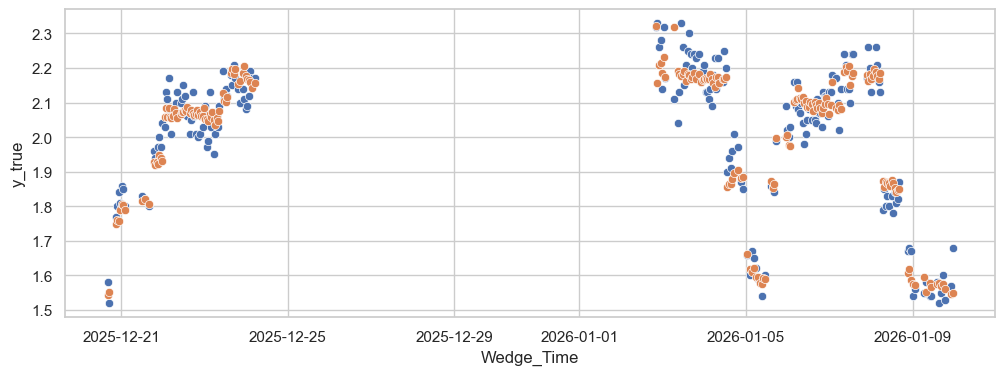

In [21]:
sns.scatterplot(df_eval[(df_eval.index>"2025-12-12") & (df_eval.index<"2026-1-10")].reset_index(), x="Wedge_Time", y="y_true")
sns.scatterplot(df_eval[(df_eval.index>"2025-12-12") & (df_eval.index<"2026-1-10")].reset_index(), x="Wedge_Time", y="y_pred")

# Plot prediction

In [28]:
exog_names

['Current_basis_weight',
 'Starch_uptake__g/m2_',
 'Actual_moisture',
 'Jet/wire_ratio',
 'Draw_PD5-SS',
 'Draw_PD3-PD4',
 'PickUp_Tension',
 'Vacuum_presszone_of_suction-press_roll',
 'Vacuum_suction_box_10',
 'Vacuum_wire_suction_box_1',
 'Top_wire_tenstion',
 'pH_measurement_white_water_B41',
 'Thick_Stock_Consistency__%_',
 'Speed_Size_Press',
 'Rod_Pressure_Bottom_Roll']

In [97]:
import cloudpickle
 
with open("model_SCTMD.pkl", "rb") as f:
    obj = cloudpickle.load(f)

In [98]:
model, exog_names = obj

In [80]:
model.predict()

array([2.59338843, 2.58849595, 2.59107614, ..., 3.3418796 , 3.34142595,
       3.34116638], shape=(289961,))

In [93]:
model.predict()

array([-0.5502887 , -0.56723551, -0.59199943, ...,  1.56720041,
        1.5662858 ,  1.5624123 ], shape=(261126,))

In [89]:
exog_names = exog_vars_

In [90]:
import pandas as pd
import numpy as np

df = pd.read_parquet(f"data/costimier_continuous.parquet").set_index("Wedge_Time")
df["retention"] = 1 - df["Consistency_white_water"] / (
    10 * df["Headbox_consistency"]
)
df = df[~df.index.duplicated(keep="first")]
df.loc[:,"Starch_uptake__g/m2_"]=df["Starch_uptake_by_paper_Bottom_Roll__g/m2_"]+df["Starch_uptake_by_paper_Top_Roll__g/m2_"]
transition_mask=df['MBS_Current_reel_ID']!=df['MBS_Current_reel_ID'].shift(-1)
itansition=np.where(transition_mask)[0]

temp=df.loc[transition_mask, "MBS_SCT_MD"]
df["MBS_SCT_MD"]=np.nan
df.loc[transition_mask,"MBS_SCT_MD"]=temp
X = df[exog_names]
y = df["MBS_SCT_MD"]

In [91]:
X_train = df[df.index < "2026-2-1"][exog_names]
y_train = df[df.index < "2026-2-1"]["MBS_SCT_MD"]

X_test = df[(df.index > "2026-2-1") & (df.index < "2026-2-10")][exog_names]
y_test = df[(df.index > "2026-2-1") & (df.index < "2026-2-10")]["MBS_SCT_MD"]

In [12]:
import seaborn as sns 

sns.set(rc={"figure.figsize":(12, 4)})
sns.set_style('whitegrid')
sns.set_context('notebook')

In [92]:
model = res

In [81]:
from tqdm import tqdm
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
 
preds = []
lower = []
upper = []
 
refit_every = 50
valid_count = 0
 
endog_refit = np.asarray(model.model.data.orig_endog).reshape(-1)
exog_refit = np.asarray(model.model.data.orig_exog) if model.model.data.orig_exog is not None else None
 
model_cls = model.model.__class__
init_kwargs = model.model._get_init_kwds().copy()
 
for i in tqdm(range(len(y_test)), total=len(y_test), desc="Recursive prediction"):
 
    x_row = X_test.iloc[[i]].to_numpy()
    y_true = y_test.iloc[i]
 
    fcst = model.get_forecast(steps=1, exog=x_row)
    y_hat = fcst.predicted_mean[0]
    ci = fcst.conf_int()
 
    preds.append(y_hat)
    lower.append(ci[0, 0])
    upper.append(ci[0, 1])
 
    if pd.notna(y_true):
        y_row = np.array([y_true])
 
        model = model.append(endog=y_row, exog=x_row, refit=False)
 
        endog_refit = np.concatenate([endog_refit, y_row])
        if exog_refit is not None:
            exog_refit = np.vstack([exog_refit, x_row])
 
        valid_count += 1
 
        if valid_count % refit_every == 0:
            print(f"Full refit at index {i}, timestamp {y_test.index[i]}")
 
            refit_mod = model_cls(
                endog=endog_refit,
                exog=exog_refit,
                **init_kwargs
            )
            model = refit_mod.fit(start_params=model.params, disp=False)
 
pred_df = pd.DataFrame(
    {
        "y_true": y_test.values,
        "y_pred": preds,
        "lower": lower,
        "upper": upper,
    },
    index=y_test.index,
)
 
df_eval = pred_df.dropna(subset=["y_true"])
 
rmse = np.sqrt(mean_squared_error(df_eval["y_true"], df_eval["y_pred"]))
mae = mean_absolute_error(df_eval["y_true"], df_eval["y_pred"])
r2 = r2_score(df_eval["y_true"], df_eval["y_pred"])
 
print("N:", len(df_eval))
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
 

Recursive prediction:  21%|██        | 2364/11307 [04:04<08:22, 17.78it/s]

Full refit at index 2368, timestamp 2026-02-02 19:01:00


Recursive prediction:  21%|██        | 2364/11307 [04:21<08:22, 17.78it/s]c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Recursive prediction:  42%|████▏     | 4768/11307 [11:44<05:29, 19.86it/s]   

Full refit at index 4776, timestamp 2026-02-04 12:19:00


Recursive prediction:  66%|██████▌   | 7437/11307 [18:04<02:51, 22.57it/s]  

Full refit at index 7441, timestamp 2026-02-07 04:29:00


Recursive prediction:  88%|████████▊ | 9979/11307 [24:36<01:15, 17.54it/s]  

Full refit at index 9984, timestamp 2026-02-09 01:57:00


Recursive prediction: 100%|██████████| 11307/11307 [29:40<00:00,  6.35it/s] 

N: 227
RMSE: 0.1210737719947157
MAE: 0.09168341209901266
R2: 0.902899226752984


<Axes: xlabel='Wedge_Time', ylabel='y_true'>

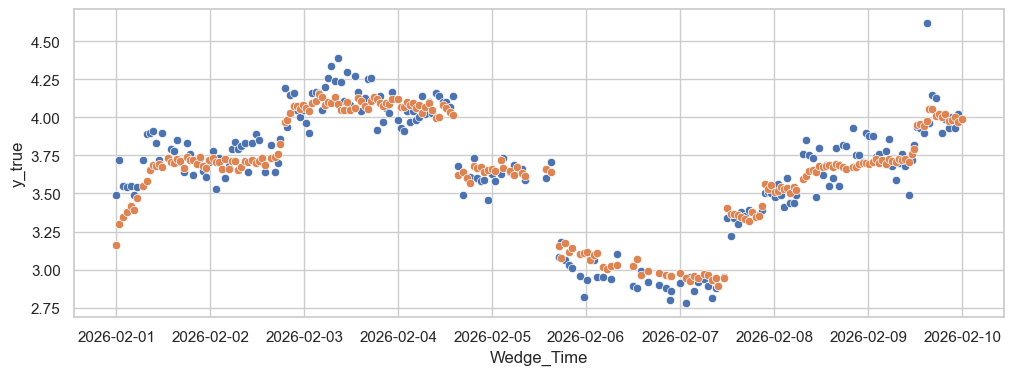

In [82]:
sns.scatterplot(df_eval.reset_index(), x="Wedge_Time", y="y_true")
sns.scatterplot(df_eval.reset_index(), x="Wedge_Time", y="y_pred")

In [14]:
df_eval

,y_true,y_pred,lower,upper
Wedge_Time,,,,
2026-02-01 00:01:00,3.49,3.162203,2.997149,3.327257
2026-02-01 00:39:00,3.72,3.297543,3.139250,3.455835
2026-02-01 01:39:00,3.55,3.347774,3.193351,3.502196
2026-02-01 02:52:00,3.54,3.377178,3.225254,3.529103
2026-02-01 03:42:00,3.55,3.419276,3.269091,3.569462
...,...,...,...,...
2026-02-09 20:34:00,3.93,3.974863,3.828713,4.121012
2026-02-09 21:24:00,4.00,3.981590,3.835440,4.127739
2026-02-09 22:13:00,3.93,4.005514,3.859364,4.151663


In [6]:
res = model

In [9]:
import shap

In [12]:
len(exog_names)

15

In [ ]:
import cloudpickle
 
with open("model_SCTMD.pkl", "rb") as f:
    obj = cloudpickle.load(f)
model, exog_names = obj
    
res = model

# -----------------------------
# 2. Extract coefficients (beta)
# -----------------------------
# Ensure correct order
beta = res.params[2:]

# -----------------------------
# 3. (Optional) intercept
# -----------------------------
# In UCM, intercept is usually part of the state (level),
# so we set it to 0 for the exogenous linear part
intercept = 0.0

# -----------------------------
# 4. Prepare data
# -----------------------------
X_train_exog = X_train[exog_names].copy()
X_test_exog = X_test[exog_names].copy()

# -----------------------------
# 5. Create SHAP LinearExplainer
# -----------------------------
explainer = shap.LinearExplainer(
    model=(beta, intercept), # linear model
    masker=X_train_exog # background data
)

# -----------------------------
# 6. Compute SHAP values
# -----------------------------
shap_values = explainer(X_test_exog)

# -----------------------------
# 7. Outputs
# -----------------------------
# SHAP values as DataFrame
shap_df = pd.DataFrame(
    shap_values.values,
    columns=exog_names,
    index=X_test_exog.index
)

# Base value (expected value)
base_value = explainer.expected_value

# Exogenous prediction
pred_exog = X_test_exog @ beta

# -----------------------------
# 8. (Optional) consistency check
# -----------------------------
reconstructed = base_value + shap_df.sum(axis=1)

print("Check (should be True):",
      np.allclose(reconstructed.values, pred_exog.values))

Check (should be True): True
